# Padronização (Standardization)

## O que é?

Padronização é o processo de **colocar variáveis diferentes na mesma escala**. Isso permite comparar escores entre variáveis que originalmente usam unidades diferentes.

A forma mais comum de padronizar é calcular o **z-score** de cada observação:

$$z = \frac{x - \bar{x}}{\sigma}$$

Onde:
- $x$ é o valor original
- $\bar{x}$ é a média da variável
- $\sigma$ é o desvio padrão

O resultado é um **escore-padrão** que indica **quantos desvios padrão** um valor está acima ou abaixo da média.

---

## Exemplo de interpretação

Um z-score de **2** significa que a observação está **2 desvios padrão acima da média**.
Um z-score de **−1.5** significa que está **1.5 desvios padrão abaixo da média**.

Essa interpretação é a mesma **independentemente da variável original** — seja peso em kg, altura em cm ou temperatura em °C.

## Qual problema resolve?

### Problema: escalas diferentes não são comparáveis

Imagine que queremos comparar:
- **Peso** (média 75 kg, desvio 10 kg)
- **Altura** (média 170 cm, desvio 8 cm)

Se uma pessoa pesa **85 kg**, está **10 kg acima da média**.
Se uma pessoa mede **178 cm**, está **8 cm acima da média**.

Qual dessas pessoas está **mais acima** da média no seu respectivo grupo? Não dá para responder diretamente — as unidades são diferentes!

### Solução: padronizar

Convertendo para z-scores:

- Peso 85 kg: $z = \frac{85 - 75}{10} = 1.0$ → **1 desvio padrão acima**
- Altura 178 cm: $z = \frac{178 - 170}{8} = 1.0$ → **1 desvio padrão acima**

Agora podemos comparar diretamente: ambas estão **na mesma posição relativa** em relação às suas respectivas distribuições.

## Propriedades da padronização

Após padronizar:

| Propriedade | Valor |
|-------------|-------|
| **Média** | 0 |
| **Desvio padrão** | 1 |
| **Unidade** | Nenhuma (adimensional) |
| **Forma da distribuição** | Mantida (não altera a forma) |

## Onde é usada?

- **Correlação de Pearson** — já vimos que divide pela covariância pelos desvios padrão
- **Regressão múltipla** — para comparar a importância relativa de features
- **Análise de clusters** — para que variáveis com escalas maiores não dominem a distância
- **Redes neurais** — para acelerar o treinamento
- **Comparação de escores** — como no exemplo peso × altura acima

## Prática com Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### Dataset simulado: peso e altura

In [2]:
np.random.seed(42)
n = 100

peso = np.random.normal(75, 10, n)  # kg
altura = np.random.normal(170, 8, n)  # cm

dados = pd.DataFrame({
    'Peso (kg)': peso,
    'Altura (cm)': altura
})

dados.describe().round(2)

,Peso (kg),Altura (cm)
count,100.00,100.00
mean,73.96,170.18
std,9.08,7.63
min,48.80,154.65
25%,68.99,163.55
50%,73.73,170.67
75%,79.06,174.31
max,93.52,191.76


### Sem padronização: não dá para comparar

In [3]:
# Pessoa A: peso 85 kg, altura 178 cm
peso_pessoa_a = 85
altura_pessoa_a = 178

print(f'Pessoa A: peso = {peso_pessoa_a} kg, altura = {altura_pessoa_a} cm')
print()
print(f'Peso acima da média: {peso_pessoa_a - dados["Peso (kg)"].mean():.1f} kg')
print(f'Altura acima da média: {altura_pessoa_a - dados["Altura (cm)"].mean():.1f} cm')
print()
print('⚠️  Qual desvio é maior? Não dá para comparar — unidades diferentes!')

Pessoa A: peso = 85 kg, altura = 178 cm

Peso acima da média: 11.0 kg
Altura acima da média: 7.8 cm

⚠️  Qual desvio é maior? Não dá para comparar — unidades diferentes!


### Padronizando: z-score

In [4]:
def z_score(x, media, desvio):
    """Calcula o z-score de um valor."""
    return (x - media) / desvio

media_peso = dados['Peso (kg)'].mean()
dp_peso = dados['Peso (kg)'].std()
media_altura = dados['Altura (cm)'].mean()
dp_altura = dados['Altura (cm)'].std()

z_peso = z_score(peso_pessoa_a, media_peso, dp_peso)
z_altura = z_score(altura_pessoa_a, media_altura, dp_altura)

print(f'Pessoa A: peso = {peso_pessoa_a} kg, altura = {altura_pessoa_a} cm')
print()
print(f'z-score do peso: {z_peso:.2f} → {abs(z_peso):.1f} desvio(s) {"acima" if z_peso > 0 else "abaixo"} da média')
print(f'z-score da altura: {z_altura:.2f} → {abs(z_altura):.1f} desvio(s) {"acima" if z_altura > 0 else "abaixo"} da média')
print()
print('✅ Agora podemos comparar! Ambas estão ~1 desvio padrão acima da média.')
print('✅ A posição relativa é a mesma, independente da unidade original.')

Pessoa A: peso = 85 kg, altura = 178 cm

z-score do peso: 1.22 → 1.2 desvio(s) acima da média
z-score da altura: 1.03 → 1.0 desvio(s) acima da média

✅ Agora podemos comparar! Ambas estão ~1 desvio padrão acima da média.
✅ A posição relativa é a mesma, independente da unidade original.


### Padronizando o dataset inteiro

In [6]:
# Padronizar todas as colunas
dados_padronizado = dados.copy()
for coluna in dados.columns:
    media = dados[coluna].mean()
    desvio = dados[coluna].std()
    dados_padronizado[f'{coluna} (z)'] = (dados[coluna] - media) / desvio

dados_padronizado.head(10)

,Peso (kg),Altura (cm),Peso (kg) (z),Altura (cm) (z)
0,79.967142,158.677034,0.661288,-1.507520
1,73.617357,166.634837,-0.037898,-0.464469
2,81.476885,167.258284,0.827528,-0.382752
3,90.230299,163.581782,1.791382,-0.864642
4,72.658466,168.709714,-0.143483,-0.192509
5,72.658630,173.232407,-0.143465,0.400292
6,90.792128,185.089487,1.853246,1.954432
7,82.674347,171.396623,0.959383,0.159671
8,70.305256,172.060403,-0.402599,0.246674
9,80.425600,169.404433,0.711769,-0.101451


### Verificando as propriedades

In [15]:
print('Após padronização:')
print()
print('Médias (devem ser ≈ 0):')
print(dados_padronizado.filter(like='(z)').mean().round(6))
print()
print('Desvios padrão (devem ser ≈ 1):')
print(dados_padronizado.filter(like='(z)').std().round(6))

Após padronização:

Médias (devem ser ≈ 0):
Peso (kg) (z)     -0.0
Altura (cm) (z)    0.0
dtype: float64

Desvios padrão (devem ser ≈ 1):
Peso (kg) (z)      1.0
Altura (cm) (z)    1.0
dtype: float64


### Visualização: antes e depois

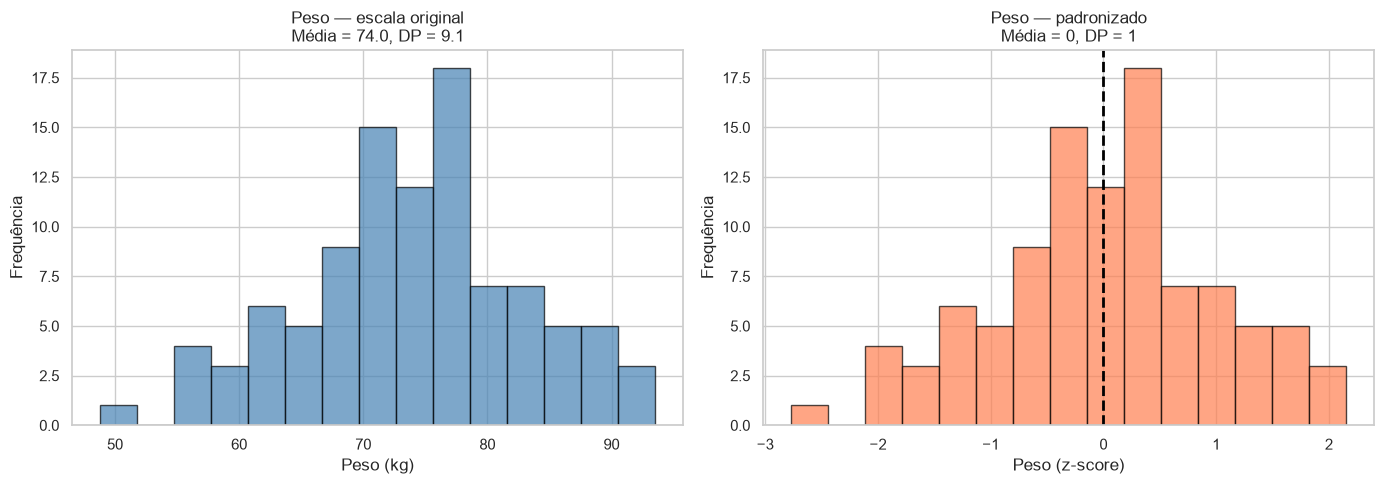

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes: escalas originais
axes[0].hist(dados['Peso (kg)'], bins=15, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Peso (kg)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Peso — escala original\nMédia = {:.1f}, DP = {:.1f}'.format(media_peso, dp_peso))

# Depois: escala padronizada
axes[1].hist(dados_padronizado['Peso (kg) (z)'], bins=15, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Peso (z-score)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Peso — padronizado\nMédia = 0, DP = 1')

plt.tight_layout()
plt.show()

### Usando pandas diretamente

In [ ]:
# pandas já tem um atalho: .std() com subtração da média
dados_z = (dados - dados.mean()) / dados.std()

dados_z.head(10)
print()
print('Médias:', dados_z.mean().round(6).to_dict())
print('DPs:', dados_z.std().round(6).to_dict())

### Usando sklearn (para ML)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dados_sklearn = pd.DataFrame(
    scaler.fit_transform(dados),
    columns=['Peso (z)', 'Altura (z)']
)

print(dados_sklearn.head(10))
print()
print('Médias:', dados_sklearn.mean().round(6).to_dict())
print('DPs:', dados_sklearn.std().round(6).to_dict())

## Resumo

| Aspecto | Antes da padronização | Depois da padronização |
|---------|----------------------|----------------------|
| **Média** | Depende dos dados | 0 |
| **Desvio padrão** | Depende dos dados | 1 |
| **Unidade** | Original (kg, cm, °C...) | Nenhuma |
| **Comparável entre variáveis?** | Não | Sim |

**Lição principal:** padronização transforma valores brutos em **quantos desvios padrão estão da média**, permitindo comparação justa entre variáveis de escalas diferentes.